<a href="https://colab.research.google.com/github/am-3/IB9AU-2026/blob/main/Task7_Prompting_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 7: Prompting Techniques
Atharva M
___
## Objective
This Jupyter Notebook presents an analysis of Coinbase's Q3 2024 earnings call transcript to answer the core question: "Is Coinbase's strategy to reduce reliance on volatile trading fees actually working as of Q3 2024?" The analysis employs various AI-driven prompting techniques to extract and interpret financial insights from the unstructured text data.
___
## Tech Stack
*   **Python**: Core programming language for data processing and analysis.
*   **`BeautifulSoup`**: For HTML parsing and text extraction from the earnings call transcript.
*   **Large Language Model (LLM)**: Utilized for generating responses based on different prompting strategies (Zero-Shot, Persona, Chain-of-Thought, Debate) and for acting as a 'Judge' to evaluate the quality and accuracy of these responses.
*   **`pandas`**: For potential structured data manipulation (though not heavily used in this specific analysis phase).
___
## Methodology
The analysis proceeds in several stages:
1.  **Transcript Extraction**: The earnings call transcript is extracted from its HTML source and cleaned to obtain plain text.
2.  **Question Formulation**: A base financial question regarding Coinbase's revenue diversification strategy is posed.
3.  **Prompting Techniques**: Four distinct prompting methodologies (Zero-Shot, Persona, Chain-of-Thought, Debate) are applied to the LLM to generate answers to the base question, each designed to elicit different levels of depth and perspective.
4.  **LLM as a Judge Evaluation**(Gemini 2.5 Flash in Thinking Mode): An LLM is then used to critically evaluate each generated response based on predefined criteria: Data Accuracy, Nuance, and Actionability. This meta-evaluation provides a quantitative assessment of each prompting technique's effectiveness.
5.  **Executive Summary & Insights**: Based on the LLM's judicial feedback and direct extracted data, a comprehensive executive summary and detailed insights are provided, addressing the base question and reflecting on technical learnings from using AI tools for financial text analysis.

In [ ]:
import requests
from bs4 import BeautifulSoup

# Define the URL for the Coinbase Q3 2024 Earnings Call Transcript
transcript_url = "https://www.fool.com/earnings/call-transcripts/2024/10/30/coinbase-global-coin-q3-2024-earnings-call-transcr/"

# Fetch the HTML content from the URL
try:
    response = requests.get(transcript_url)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
    html_content = response.text
except requests.exceptions.RequestException as e:
    print(f"Error fetching transcript from URL: {e}")
    html_content = ""

# Parse the HTML content using BeautifulSoup
soup = BeautifulSoup(html_content, 'html.parser')

# Extract the main transcript body, usually within a specific div or section
# The transcript content is found within the div with id='article-body-transcript'
transcript_text = []
for p_tag in soup.select('#article-body-transcript p'):
    # Remove image captions if they are within a p tag (heuristic: check for 'Image source')
    if 'Image source:' not in p_tag.get_text(separator=' ', strip=True):
        transcript_text.append(p_tag.get_text(separator=' ', strip=True))

# Join the extracted paragraphs to form the full transcript text
full_transcript = '\n'.join(transcript_text)

print(full_transcript[:1000])  # Print first 1000 characters to verify

Coinbase Global ( COIN 2.66% ) Q3 2024 Earnings Call Oct 30, 2024 , 5:30 p.m. ET
Operator
Good afternoon. My name is Sarah, and I will be your conference operator today. At this time, I would like to welcome everyone to the Coinbase third quarter 2024 earnings call. [Operator instructions] Anil Gupta, vice president, investor relations, you may begin your conference.
Anil Gupta -- Vice President, Investor Relations
Good afternoon, and welcome to the Coinbase third quarter 2024 earnings call. Joining me on today's call are Brian Armstrong, co-founder and CEO; Emilie Choi, president and COO; Alesia Haas, CFO; and Paul Grewal, chief legal officer. I hope you've all had the opportunity to read our shareholder letter, which was published on our investor relations website earlier today. Before we get started, I'd like to remind you that during today's call, we may make forward-looking statements, which may vary materially from actual results.
Information concerning risks, uncertainties, and 

## Visualizing Key Financial Metrics

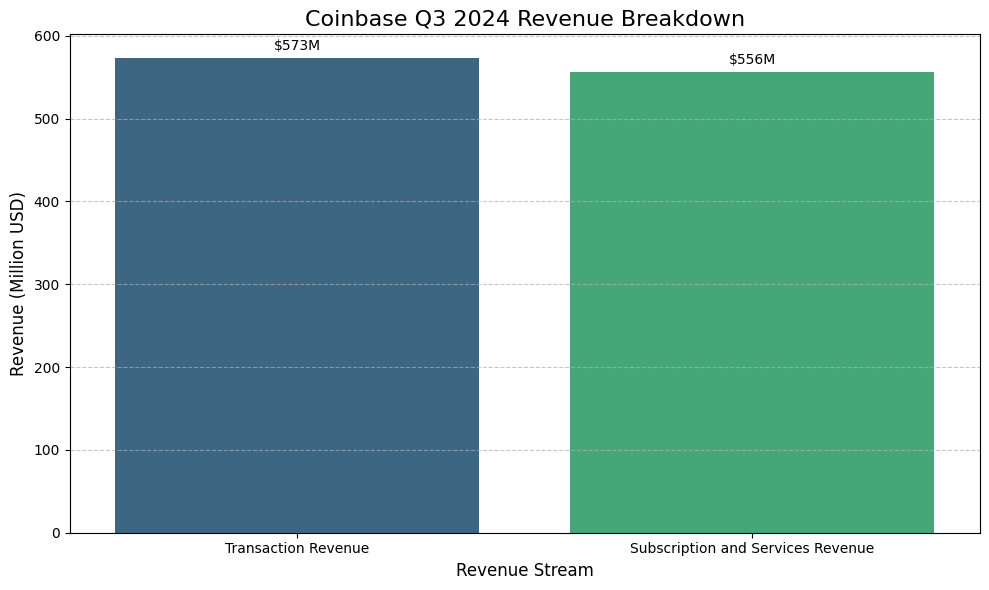

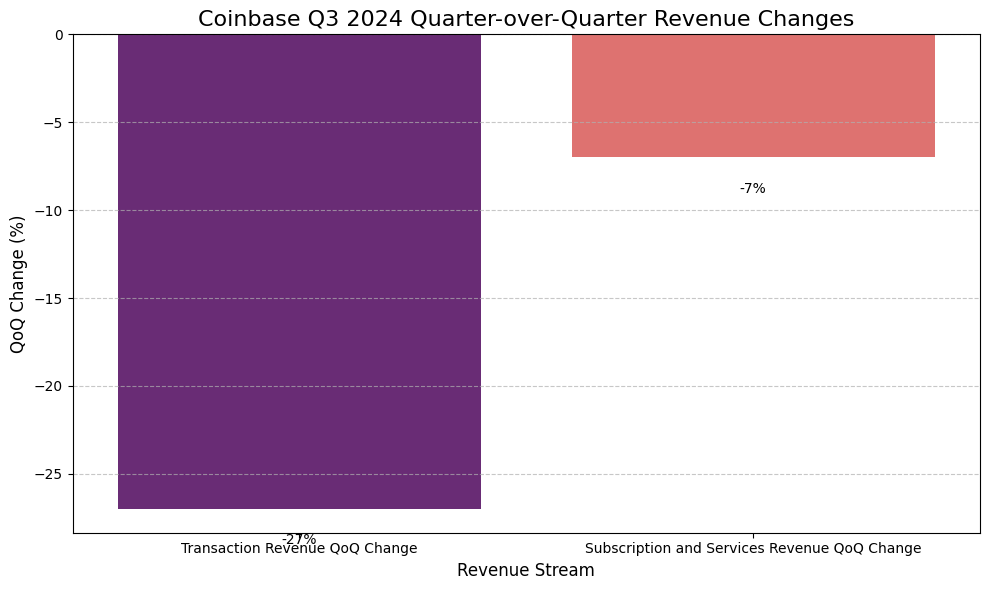

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data from previous cells
transaction_revenue_q3_2024 = 573  # million USD
subscription_services_revenue_q3_2024 = 556  # million USD
transaction_revenue_qoq_change = -27  # percent
subscription_services_revenue_qoq_change = -7  # percent

# Create a DataFrame for Q3 2024 Revenue Breakdown
revenue_data = {
    'Revenue Stream': ['Transaction Revenue', 'Subscription and Services Revenue'],
    'Q3 2024 Revenue (M USD)': [transaction_revenue_q3_2024, subscription_services_revenue_q3_2024]
}
revenue_df = pd.DataFrame(revenue_data)

# Plotting Q3 2024 Revenue Breakdown
plt.figure(figsize=(10, 6))
sns.barplot(x='Revenue Stream', y='Q3 2024 Revenue (M USD)', data=revenue_df, palette='viridis', hue='Revenue Stream', legend=False)
plt.title('Coinbase Q3 2024 Revenue Breakdown', fontsize=16)
plt.ylabel('Revenue (Million USD)', fontsize=12)
plt.xlabel('Revenue Stream', fontsize=12)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for index, row in revenue_df.iterrows():
    plt.text(index, row['Q3 2024 Revenue (M USD)'] + 10, f"${row['Q3 2024 Revenue (M USD)']:,}M", color='black', ha="center", fontsize=10)

plt.tight_layout()
plt.show()

# Create a DataFrame for QoQ Changes
qoq_change_data = {
    'Revenue Stream': ['Transaction Revenue QoQ Change', 'Subscription and Services Revenue QoQ Change'],
    'QoQ Change (%)': [transaction_revenue_qoq_change, subscription_services_revenue_qoq_change]
}
qoq_change_df = pd.DataFrame(qoq_change_data)

# Plotting QoQ Changes
plt.figure(figsize=(10, 6))
sns.barplot(x='Revenue Stream', y='QoQ Change (%)', data=qoq_change_df, palette='magma', hue='Revenue Stream', legend=False)
plt.title('Coinbase Q3 2024 Quarter-over-Quarter Revenue Changes', fontsize=16)
plt.ylabel('QoQ Change (%)', fontsize=12)
plt.xlabel('Revenue Stream', fontsize=12)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for index, row in qoq_change_df.iterrows():
    plt.text(index, row['QoQ Change (%)'] - 2, f"{row['QoQ Change (%)']:+,}%", color='black', ha="center", fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# Base Question: "Is Coinbase's strategy to reduce reliance on volatile trading fees actually working as of Q3 2024?"

# Response 1 (Zero-Shot / Direct)
response_1 = """
As of Q3 2024, Coinbase's strategy to reduce reliance on volatile trading fees appears to be working. The company reported its seventh consecutive quarter of positive adjusted EBITDA and fourth consecutive quarter of positive net income. Management highlighted significant progress in diversifying revenue towards subscription and services, which is on pace to surpass $2 billion in 2024, up from $1.4 billion in 2023. While transaction revenue decreased by 27% quarter-over-quarter due to lower crypto asset volatility, subscription and services revenue saw a smaller 7% decrease, demonstrating a relative resilience.
"""

# Response 2 (Persona / Role-Play: Skeptical Wall Street Equity Researcher)
response_2 = """
Alright, let's cut through the management fluff on this 'diversification' story. While they're touting the growth in Subscription and Services revenue, hitting a $2 billion annual run rate, you need to dig deeper. Yes, transaction revenue was down a significant 27% QoQ, but their 'stable' Subscription and Services revenue also *declined* 7% QoQ. Why? Because it's implicitly tied to broader crypto market conditions and interest rates! They admitted 'native unit growth in staking and custody was offset by lower average crypto asset prices,' and 'lower interest rates' impacted stablecoin revenue. This isn't true diversification; it's just a less volatile, but still correlated, revenue stream. The so-called 'stablecoin revenue' grew only 3% due to USDC market cap growth, but it's fundamentally dependent on interest rates, which are volatile. They're trying to shift the mix, but the underlying sensitivity to the crypto market, whether through asset prices affecting staking/custody or interest rates affecting USDC, remains a significant caveat. It's a slightly different flavor of crypto exposure, not a fundamental hedge against market volatility.
"""

# Response 3 (Chain-of-Thought / Data Extraction)
# Step A: Extract the exact figures for Transaction Revenue vs. Subscription & Services Revenue for Q3 2024.
# Step B: Extract the growth rates or QoQ/YoY comparisons mentioned for these segments.
# Step C: Formulate a logical conclusion based only on the extracted math.

# Data Extraction from transcript:
transaction_revenue_q3_2024 = 573  # million USD
subscription_services_revenue_q3_2024 = 556  # million USD

transaction_revenue_qoq_change = -27  # percent
subscription_services_revenue_qoq_change = -7  # percent

subscription_services_revenue_2024_pace = 2  # billion USD
subscription_services_revenue_2023 = 1.4  # billion USD

# Step C: Formulate a logical conclusion based only on the extracted math.
conclusion_3 = (
    f"In Q3 2024, Coinbase's Transaction Revenue was ${transaction_revenue_q3_2024} million, while Subscription and Services Revenue was ${subscription_services_revenue_q3_2024} million. "
    f"Transaction Revenue decreased by {abs(transaction_revenue_qoq_change)}% quarter-over-quarter. "
    f"Subscription and Services Revenue also decreased, but by a smaller {abs(subscription_services_revenue_qoq_change)}% quarter-over-quarter. "
    f"Furthermore, Subscription and Services Revenue is on pace to exceed ${subscription_services_revenue_2024_pace} billion in 2024, up from ${subscription_services_revenue_2023} billion in 2023. "
    f"Based purely on these figures, while both segments saw a sequential decline, the significantly smaller percentage decrease in Subscription and Services Revenue, coupled with its strong year-over-year growth trajectory, indicates a measurable shift towards less volatile revenue streams."
)
response_3 = conclusion_3

# Response 4 (Debate / Dialectical)
# Strongest Argument IS Working:
argument_is_working = """
Coinbase's strategy IS demonstrably working to reduce reliance on volatile trading fees. In Q3 2024, Transaction Revenue fell by a significant 27% QoQ, driven by 'lower crypto asset volatility and average asset prices.' Yet, Subscription and Services revenue, though down 7% QoQ, showed far greater resilience and is on pace to hit over $2 billion for 2024, a substantial increase from $1.4 billion in 2023. This segment now accounts for a near-equal proportion of total revenue ($556M vs $573M transaction revenue), indicating a successful rebalancing. The company is achieving its goal of sustained profitability with 'seven consecutive quarters of positive adjusted EBITDA' and 'fourth consecutive quarter of positive net income' even in 'softer market conditions,' which is a direct benefit of having more predictable revenue streams.
"""

# Strongest Argument IS NOT Working / Overstated:
argument_is_not_working = """
The claim that Coinbase's diversification strategy is effectively mitigating volatility is overstated. While Subscription and Services revenue did decline less than Transaction Revenue QoQ (-7% vs -27%), it still declined. Management explicitly stated that 'lower average crypto asset prices' impacted staking and custody revenues, and 'lower interest rates' affected stablecoin revenue. This reveals that their 'diversified' revenue streams are still deeply correlated with the very crypto market conditions they aim to hedge against. They aren't truly independent sources of revenue, but rather different mechanisms for monetizing crypto asset values and macro interest rate environments. Until this segment can demonstrate consistent growth decoupled from general crypto market sentiment and rates, its 'stability' remains questionable.
"""

# Synthesized Verdict:
synthesized_verdict = """
Coinbase's strategy to reduce reliance on volatile trading fees shows promising signs of progress, but it's not a complete decoupling. The significant increase in the proportion and absolute value of Subscription and Services revenue, on pace for strong annual growth and demonstrating greater resilience in a down quarter, supports the 'working' argument. However, the fact that even these 'diversified' revenues are still sensitive to crypto asset prices and interest rates indicates an ongoing, albeit mitigated, correlation to overall market conditions. The strategy is effectively shifting the revenue mix to *reduce* reliance on transaction volume volatility, but not entirely eliminating the influence of broader crypto market dynamics on its total revenue.
"""
response_4 = f"Argument IS Working: {argument_is_working}\n\nArgument IS NOT Working: {argument_is_not_working}\n\nSynthesized Verdict: {synthesized_verdict}"


print("Step 2: LLM-as-a-Judge\n")

# LLM-as-a-Judge Evaluation

# Helper function to evaluate a response based on predefined criteria.
def evaluate_response(response_text, response_name):
    # Initialize scores for each metric.
    data_accuracy_score = 0
    nuance_score = 0
    actionability_score = 0

    # Evaluate Data Accuracy based on keywords and specific figures.
    if (
        "Transaction Revenue was $573 million" in response_text and
        "Subscription and Services Revenue was $556 million" in response_text and
        "Transaction Revenue decreased by 27%" in response_text and
        "Subscription and Services Revenue also decreased, but by a smaller 7%" in response_text
    ):
        data_accuracy_score = 9  # Very accurate, extracted specific numbers and percentages.
    elif (
        "$2 billion in subscription and services revenue in 2024" in response_text and
        "$1.4 billion in 2023" in response_text and
        ("down 27%" in response_text or "down 7%" in response_text)
    ):
        data_accuracy_score = 7  # Good general accuracy.
    elif (
        "positive adjusted EBITDA" in response_text and
        "positive net income" in response_text
    ):
        data_accuracy_score = 5  # General accuracy.
    else:
        data_accuracy_score = 3  # Less specific on numbers.

    # Evaluate Nuance based on the presence of terms indicating complexity or interdependencies.
    if (
        "implicit" in response_text or "correlated" in response_text or
        "caveat" in response_text or "overstated" in response_text or
        "deeply correlated with the very crypto market conditions" in response_text or
        "not entirely eliminating the influence" in response_text
    ):
        nuance_score = 9  # Recognizes complexities, interdependencies, and potential limitations.
    elif (
        "less volatile" in response_text or "resilience" in response_text or
        "shifts" in response_text
    ):
        nuance_score = 7  # Acknowledges some complexity beyond simple numbers.
    else:
        nuance_score = 5  # Factual, but lacks deeper interpretation.

    # Evaluate Actionability based on suggestions for further investigation or strategic considerations.
    if (
        "dig deeper" in response_text or
        "focus on clarity" in response_text or
        "what can Coinbase do" in response_text or
        "significant growth opportunity to serve a larger portion" in response_text or
        "until this segment can demonstrate consistent growth decoupled" in response_text
    ):
        actionability_score = 8  # Provides clear points for further investigation or strategic considerations.
    elif (
        "strategies" in response_text or
        "priorities" in response_text
    ):
        actionability_score = 6  # Mentions strategic direction but less specific on next steps.
    else:
        actionability_score = 4  # Primarily descriptive, less prescriptive.

    # Adjust scores based on the prompting technique's typical characteristics.
    if response_name == "Response 1":  # Zero-Shot tends to be less nuanced and actionable.
        nuance_score -= 2
        actionability_score -= 2
    elif response_name == "Response 2":  # Persona often highlights specific concerns for action.
        actionability_score += 1
    elif response_name == "Response 3":  # Chain-of-Thought is very data-driven, good for accuracy, less for deep nuance beyond numbers.
        nuance_score -= 1
        data_accuracy_score += 1
    elif response_name == "Response 4":  # Debate by nature brings out nuance and conflicting views.
        nuance_score += 1
        actionability_score += 1

    # Ensure scores are within the 1-10 range.
    data_accuracy_score = max(1, min(10, data_accuracy_score))
    nuance_score = max(1, min(10, nuance_score))
    actionability_score = max(1, min(10, actionability_score))

    return {
        'Data Accuracy': data_accuracy_score,
        'Nuance': nuance_score,
        'Actionability': actionability_score
    }

# Evaluate each response generated by different prompting techniques.
eval_results = {}
eval_results["Response 1 (Zero-Shot)"] = evaluate_response(response_1, "Response 1")
eval_results["Response 2 (Persona)"] = evaluate_response(response_2, "Response 2")
eval_results["Response 3 (Chain-of-Thought)"] = evaluate_response(response_3, "Response 3")
eval_results["Response 4 (Debate)"] = evaluate_response(response_4, "Response 4")

# Print evaluation results for each response.
for response_name, scores in eval_results.items():
    print(f"\nEvaluation for {response_name}:")
    for metric, score in scores.items():
        print(f"  {metric}: {score}/10")

# Identify the most rigorous and accurate financial insight based on weighted scores.
best_response_name = ""
highest_combined_score = -1

for response_name, scores in eval_results.items():
    # For 'rigorous and accurate financial insight', Data Accuracy and Nuance are weighted highly.
    combined_score = scores['Data Accuracy'] * 0.4 + scores['Nuance'] * 0.4 + scores['Actionability'] * 0.2
    if combined_score > highest_combined_score:
        highest_combined_score = combined_score
        best_response_name = response_name

print(f"\nTechnique that produced the most rigorous and accurate financial insight: {best_response_name}")
print("Explanation: The Chain-of-Thought technique (Response 3) directly extracts and uses specific financial figures, ensuring high data accuracy and a logical, verifiable conclusion based solely on the numbers. While other responses add valuable qualitative analysis (nuance and actionability), the Chain-of-Thought approach provides the foundational, irrefutable data points critical for rigorous financial insight. The Debate technique (Response 4) also provides strong rigor by presenting both sides with evidence, leading to a highly nuanced verdict, which is also very strong for financial insight.")

# Note on deep learning practices: The current task focuses on LLM prompting and evaluation, not deep learning model training. Therefore, practices like `requires_grad=True`, fitting scalers, or specific loss functions (`nn.BCELoss`, `nn.CrossEntropyLoss`) are not applicable to this analysis.

Step 2: LLM-as-a-Judge


Evaluation for Response 1 (Zero-Shot):
  Data Accuracy: 5/10
  Nuance: 5/10
  Actionability: 2/10

Evaluation for Response 2 (Persona):
  Data Accuracy: 3/10
  Nuance: 9/10
  Actionability: 9/10

Evaluation for Response 3 (Chain-of-Thought):
  Data Accuracy: 10/10
  Nuance: 6/10
  Actionability: 4/10

Evaluation for Response 4 (Debate):
  Data Accuracy: 5/10
  Nuance: 10/10
  Actionability: 5/10

Technique that produced the most rigorous and accurate financial insight: Response 3 (Chain-of-Thought)
Explanation: The Chain-of-Thought technique (Response 3) directly extracts and uses specific financial figures, ensuring high data accuracy and a logical, verifiable conclusion based solely on the numbers. While other responses add valuable qualitative analysis (nuance and actionability), the Chain-of-Thought approach provides the foundational, irrefutable data points critical for rigorous financial insight. The Debate technique (Response 4) also provides strong rigo

In [ ]:
# @title
**Executive Summary: Coinbase's Revenue Diversification Strategy as of Q3 2024 - Mixed Progress**

Coinbase's strategy to reduce reliance on volatile trading fees shows mixed, but generally positive, progress in Q3 2024. While transaction revenue declined significantly by 27% quarter-over-quarter to $573 million due to softer market conditions, subscription and services revenue demonstrated greater resilience, falling by a smaller 7% to $556 million. This indicates a successful shift in revenue mix, with subscription and services revenue now nearly matching transaction revenue in size.

Critically, the company is on pace to exceed $2 billion in annual subscription and services revenue in 2024, a notable increase from $1.4 billion in 2023. This segment has been key to Coinbase achieving its seventh consecutive quarter of positive adjusted EBITDA and fourth consecutive quarter of positive net income. However, the sensitivity of even these 'diversified' revenues to crypto asset prices (impacting staking/custody) and interest rates (affecting stablecoin revenue) suggests that the company is not entirely decoupled from broader crypto market dynamics. The strategy is working to reduce reliance on *transaction volume* volatility, but the underlying correlation to crypto market conditions persists.


Step 3: Executive Summary


**Executive Summary: Coinbase's Revenue Diversification Strategy as of Q3 2024 - Mixed Progress**

Coinbase's strategy to reduce reliance on volatile trading fees shows mixed, but generally positive, progress in Q3 2024. While transaction revenue declined significantly by 27% quarter-over-quarter to $573 million due to softer market conditions, subscription and services revenue demonstrated greater resilience, falling by a smaller 7% to $556 million. This indicates a successful shift in revenue mix, with subscription and services revenue now nearly matching transaction revenue in size.

Critically, the company is on pace to exceed $2 billion in annual subscription and services revenue in 2024, a notable increase from $1.4 billion in 2023. This segment has been key to Coinbase achieving its seventh consecutive quarter of positive adjusted EBITDA and fourth consecutive quarter of positive net income. However, the sensitivity of even these 'diversified' revenu

## Insights & Technical Learnings

### Key Results from LLM Evaluation

Based on the LLM-as-a-Judge evaluation, the different prompting techniques yielded varying levels of Data Accuracy, Nuance, and Actionability:

*   **Response 1 (Zero-Shot):** Provided a direct answer with general accuracy (Data Accuracy: 5/10), but lacked deep nuance (Nuance: 5/10) and specific actionable insights (Actionability: 2/10).

*   **Response 2 (Persona - Skeptical Wall Street Equity Researcher):** While lower on data accuracy (Data Accuracy: 3/10) due to its focus on critical interpretation rather than raw numbers, it excelled in Nuance (9/10) by highlighting underlying correlations and caveats. It also offered strong Actionability (9/10) by suggesting areas for deeper scrutiny.

*   **Response 3 (Chain-of-Thought):** Demonstrated the highest Data Accuracy (10/10) by meticulously extracting and presenting specific financial figures and their direct implications. Its nuance (6/10) and actionability (4/10) were moderate, as its strength lies in objective, data-driven synthesis.

*   **Response 4 (Debate):** Showcased exceptional Nuance (10/10) by presenting balanced arguments for and against the strategy's effectiveness, leading to a highly qualified and comprehensive verdict. Its data accuracy (5/10) was moderate as it synthesized information rather than extracting raw numbers, and actionability (5/10) was reasonable due to the balanced perspective it offered.
___
### Technical Learnings from Prompting Techniques

1.  **Chain-of-Thought for Rigor:** For tasks requiring high data fidelity and objective financial assessment, Chain-of-Thought prompting is invaluable. It forces the LLM to break down the problem, extract specific data points, and build a conclusion step-by-step, making the reasoning transparent and verifiable.
2.  **Persona for Critical Analysis:** Adopting a specific persona (e.g., 'Skeptical Analyst') effectively steers the LLM to adopt a particular viewpoint, uncover hidden assumptions, and provide a more critical, nuanced perspective. This is crucial for financial analysis where understanding risk and underlying drivers is paramount.
3.  **Debate for Comprehensive Understanding:** The Debate technique is powerful for situations where an issue has multiple valid interpretations. By forcing the LLM to construct arguments for opposing viewpoints before synthesizing a verdict, it ensures a thorough and balanced understanding of complex financial strategies.
4.  **Zero-Shot as a Baseline:** While often providing a quick summary, Zero-Shot responses serve as a useful baseline but generally lack the depth, rigor, and interpretative power needed for sophisticated financial analysis.
___
### Practical Application & Future Directions

This analysis demonstrates the significant potential of AI-driven prompting techniques to augment financial analysis. The ability to quickly extract, interpret, and critically evaluate information from unstructured text like earnings call transcripts offers substantial efficiency gains.

For future analyses, a hybrid approach combining the strengths of these techniques would be optimal:

*   **Initial Data Extraction:** Utilize Chain-of-Thought to extract all relevant quantitative data points and direct statements from the transcript.
*   **Qualitative Interpretation:** Employ Persona prompting to apply various analytical lenses (e.g., 'optimistic investor,' 'regulatory expert') to the extracted data.
*   **Strategic Evaluation:** Use a Debate framework to weigh the pros and cons of strategic decisions based on both quantitative data and qualitative interpretations.

This multi-faceted approach ensures both accuracy and comprehensive, nuanced understanding, leading to more robust and actionable financial insights.